In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline

In [2]:
data = pd.read_csv('book_reviews_sample.csv')
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   index       100 non-null    int64
 1   reviewText  100 non-null    str  
 2   rating      100 non-null    int64
dtypes: int64(2), str(1)
memory usage: 2.5 KB


In [4]:
data['reviewText'][0]

'Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.'

# Text cleaning

## Lowercasing the text

In [5]:
data['reviewText_lowercase'] = data['reviewText'].str.lower()
data.head()

,index,reviewText,rating,reviewText_lowercase
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin..."
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


## Removing stopwords

In [6]:
en_stopwords = stopwords.words('english')
data['reviewText_with_no_stopwords'] = data['reviewText_lowercase'].apply(lambda x: ' '.join([word for word in x.split() if word not in en_stopwords]))
data.head()

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin..."
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot


## Removing punctuations

In [7]:
data['reviewText_with_no_punc'] = data.apply(lambda x: re.sub(r"[^\w\s]", "", x['reviewText_lowercase']), axis=1)
data.head()

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords,reviewText_with_no_punc
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,this was hands down the worse book i have ever...


In [8]:
data['reviewText_with_no_stopwords_no_punc'] = data.apply(lambda x: re.sub(r"[^\w\s]", "", x['reviewText_with_no_stopwords']), axis=1)
data.head()

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords,reviewText_with_no_punc,reviewText_with_no_stopwords_no_punc
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...,clean and funny a bit busy with all the differ...,clean funny bit busy different plots going on ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...,alex a sexy hot cop and the phd candidate what...,alex sexy hot cop phd candidate match makes gr...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.,good thing that this is a free story i read it...,good thing free story read years ago worth time
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,this was hands down the worse book i have ever...,hands worse book ever read trst says alot


## Tokenizing the text

In [9]:
data['reviewText_tokenx_raw'] = data.apply(lambda x: word_tokenize(x['reviewText_lowercase']), axis=1)
data['reviewText_tokens_clean'] = data.apply(lambda x: word_tokenize(x['reviewText_with_no_stopwords_no_punc']), axis=1)

In [10]:
data.head()

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords,reviewText_with_no_punc,reviewText_with_no_stopwords_no_punc,reviewText_tokenx_raw,reviewText_tokens_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...,clean and funny a bit busy with all the differ...,clean funny bit busy different plots going on ...,"[clean, and, funny, ., a, bit, busy, with, all...","[clean, funny, bit, busy, different, plots, go..."
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...,alex a sexy hot cop and the phd candidate what...,alex sexy hot cop phd candidate match makes gr...,"[alex, a, sexy, hot, cop, and, the, phd, candi...","[alex, sexy, hot, cop, phd, candidate, match, ..."
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.,good thing that this is a free story i read it...,good thing free story read years ago worth time,"[good, thing, that, this, is, a, free, story, ...","[good, thing, free, story, read, years, ago, w..."
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...,action action action equipment keeps getting b...,"[action, ,, action, ,, action, !, equipment, k...","[action, action, action, equipment, keeps, get..."
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,"[this, was, hands, down, the, worse, book, i, ...","[hands, worse, book, ever, read, trst, says, a..."


## Lemmatizing the text

In [11]:
lemmatizer = WordNetLemmatizer()
data['reviewText_lemmatized'] = data['reviewText_tokens_clean'].apply(lambda x: [lemmatizer.lemmatize(token) for token in x])
data.head()

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords,reviewText_with_no_punc,reviewText_with_no_stopwords_no_punc,reviewText_tokenx_raw,reviewText_tokens_clean,reviewText_lemmatized
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...,clean and funny a bit busy with all the differ...,clean funny bit busy different plots going on ...,"[clean, and, funny, ., a, bit, busy, with, all...","[clean, funny, bit, busy, different, plots, go...","[clean, funny, bit, busy, different, plot, goi..."
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...,alex a sexy hot cop and the phd candidate what...,alex sexy hot cop phd candidate match makes gr...,"[alex, a, sexy, hot, cop, and, the, phd, candi...","[alex, sexy, hot, cop, phd, candidate, match, ...","[alex, sexy, hot, cop, phd, candidate, match, ..."
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.,good thing that this is a free story i read it...,good thing free story read years ago worth time,"[good, thing, that, this, is, a, free, story, ...","[good, thing, free, story, read, years, ago, w...","[good, thing, free, story, read, year, ago, wo..."
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...,action action action equipment keeps getting b...,"[action, ,, action, ,, action, !, equipment, k...","[action, action, action, equipment, keeps, get...","[action, action, action, equipment, keep, gett..."
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,"[this, was, hands, down, the, worse, book, i, ...","[hands, worse, book, ever, read, trst, says, a...","[hand, worse, book, ever, read, trst, say, alot]"


In [13]:
data = data.rename(columns={'reviewText_with_no_punc': 'reviewText_clean'})

In [14]:
data.head()

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords,reviewText_clean,reviewText_with_no_stopwords_no_punc,reviewText_tokenx_raw,reviewText_tokens_clean,reviewText_lemmatized
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...,clean and funny a bit busy with all the differ...,clean funny bit busy different plots going on ...,"[clean, and, funny, ., a, bit, busy, with, all...","[clean, funny, bit, busy, different, plots, go...","[clean, funny, bit, busy, different, plot, goi..."
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...,alex a sexy hot cop and the phd candidate what...,alex sexy hot cop phd candidate match makes gr...,"[alex, a, sexy, hot, cop, and, the, phd, candi...","[alex, sexy, hot, cop, phd, candidate, match, ...","[alex, sexy, hot, cop, phd, candidate, match, ..."
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.,good thing that this is a free story i read it...,good thing free story read years ago worth time,"[good, thing, that, this, is, a, free, story, ...","[good, thing, free, story, read, years, ago, w...","[good, thing, free, story, read, year, ago, wo..."
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...,action action action equipment keeps getting b...,"[action, ,, action, ,, action, !, equipment, k...","[action, action, action, equipment, keeps, get...","[action, action, action, equipment, keep, gett..."
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,"[this, was, hands, down, the, worse, book, i, ...","[hands, worse, book, ever, read, trst, says, a...","[hand, worse, book, ever, read, trst, say, alot]"


# Sentiment Analysis

In [12]:
vader_sentiment = SentimentIntensityAnalyzer()

In [15]:
data['reviewText_sentiment_score'] = data['reviewText_clean'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])

In [16]:
data.head()

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords,reviewText_clean,reviewText_with_no_stopwords_no_punc,reviewText_tokenx_raw,reviewText_tokens_clean,reviewText_lemmatized,reviewText_sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...,clean and funny a bit busy with all the differ...,clean funny bit busy different plots going on ...,"[clean, and, funny, ., a, bit, busy, with, all...","[clean, funny, bit, busy, different, plots, go...","[clean, funny, bit, busy, different, plot, goi...",0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...,alex a sexy hot cop and the phd candidate what...,alex sexy hot cop phd candidate match makes gr...,"[alex, a, sexy, hot, cop, and, the, phd, candi...","[alex, sexy, hot, cop, phd, candidate, match, ...","[alex, sexy, hot, cop, phd, candidate, match, ...",0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.,good thing that this is a free story i read it...,good thing free story read years ago worth time,"[good, thing, that, this, is, a, free, story, ...","[good, thing, free, story, read, years, ago, w...","[good, thing, free, story, read, year, ago, wo...",0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...,action action action equipment keeps getting b...,"[action, ,, action, ,, action, !, equipment, k...","[action, action, action, equipment, keeps, get...","[action, action, action, equipment, keep, gett...",0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,"[this, was, hands, down, the, worse, book, i, ...","[hands, worse, book, ever, read, trst, says, a...","[hand, worse, book, ever, read, trst, say, alot]",-0.4767


In [17]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

In [18]:
data['reviewText_sentiment_labels'] = pd.cut(data['reviewText_sentiment_score'], bins, labels=names)

In [19]:
data.head()

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords,reviewText_clean,reviewText_with_no_stopwords_no_punc,reviewText_tokenx_raw,reviewText_tokens_clean,reviewText_lemmatized,reviewText_sentiment_score,reviewText_sentiment_labels
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...,clean and funny a bit busy with all the differ...,clean funny bit busy different plots going on ...,"[clean, and, funny, ., a, bit, busy, with, all...","[clean, funny, bit, busy, different, plots, go...","[clean, funny, bit, busy, different, plot, goi...",0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...,alex a sexy hot cop and the phd candidate what...,alex sexy hot cop phd candidate match makes gr...,"[alex, a, sexy, hot, cop, and, the, phd, candi...","[alex, sexy, hot, cop, phd, candidate, match, ...","[alex, sexy, hot, cop, phd, candidate, match, ...",0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.,good thing that this is a free story i read it...,good thing free story read years ago worth time,"[good, thing, that, this, is, a, free, story, ...","[good, thing, free, story, read, years, ago, w...","[good, thing, free, story, read, year, ago, wo...",0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...,action action action equipment keeps getting b...,"[action, ,, action, ,, action, !, equipment, k...","[action, action, action, equipment, keeps, get...","[action, action, action, equipment, keep, gett...",0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,"[this, was, hands, down, the, worse, book, i, ...","[hands, worse, book, ever, read, trst, says, a...","[hand, worse, book, ever, read, trst, say, alot]",-0.4767,negative


In [20]:
data

,index,reviewText,rating,reviewText_lowercase,reviewText_with_no_stopwords,reviewText_clean,reviewText_with_no_stopwords_no_punc,reviewText_tokenx_raw,reviewText_tokens_clean,reviewText_lemmatized,reviewText_sentiment_score,reviewText_sentiment_labels
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...,clean funny. bit busy different plots going on...,clean and funny a bit busy with all the differ...,clean funny bit busy different plots going on ...,"[clean, and, funny, ., a, bit, busy, with, all...","[clean, funny, bit, busy, different, plots, go...","[clean, funny, bit, busy, different, plot, goi...",0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...,alex sexy hot cop phd candidate. match makes g...,alex a sexy hot cop and the phd candidate what...,alex sexy hot cop phd candidate match makes gr...,"[alex, a, sexy, hot, cop, and, the, phd, candi...","[alex, sexy, hot, cop, phd, candidate, match, ...","[alex, sexy, hot, cop, phd, candidate, match, ...",0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...,good thing free story. read years ago worth time.,good thing that this is a free story i read it...,good thing free story read years ago worth time,"[good, thing, that, this, is, a, free, story, ...","[good, thing, free, story, read, years, ago, w...","[good, thing, free, story, read, year, ago, wo...",0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin...","action, action, action! equipment keeps gettin...",action action action equipment keeps getting b...,action action action equipment keeps getting b...,"[action, ,, action, ,, action, !, equipment, k...","[action, action, action, equipment, keeps, get...","[action, action, action, equipment, keep, gett...",0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,this was hands down the worse book i have ever...,hands worse book ever read trst says alot,"[this, was, hands, down, the, worse, book, i, ...","[hands, worse, book, ever, read, trst, says, a...","[hand, worse, book, ever, read, trst, say, alot]",-0.4767,negative
...,...,...,...,...,...,...,...,...,...,...,...,...
95,1794,Love this author. I have read most of her book...,5,love this author. i have read most of her book...,"love author. read books, again, disappoint!!!!",love this author i have read most of her books...,love author read books again disappoint,"[love, this, author, ., i, have, read, most, o...","[love, author, read, books, again, disappoint]","[love, author, read, book, again, disappoint]",0.7549,positive
96,6716,This book was not bad! I like the storyline ! ...,2,this book was not bad! i like the storyline ! ...,book bad! like storyline ! sex grate much it!,this book was not bad i like the storyline th...,book bad like storyline sex grate much it,"[this, book, was, not, bad, !, i, like, the, s...","[book, bad, like, storyline, sex, grate, much,...","[book, bad, like, storyline, sex, grate, much,...",0.1877,positive
97,7372,This is part of a series I read and I loved th...,5,this is part of a series i read and i loved th...,part series read loved whole series also kindle.,this is part of a series i read and i loved th...,part series read loved whole series also kindle,"[this, is, part, of, a, series, i, read, and, ...","[part, series, read, loved, whole, series, als...","[part, series, read, loved, whole, series, als...",0.5994,positive
98,5676,Finally a Texas newspaper in Kindle format.Way...,4,finally a texas newspaper in kindle format.way...,finally texas newspaper kindle format.way go a...,finally a texas newspaper in kindle formatway ...,finally texas newspaper kindle formatway go am...,"[finally, a, texas, newspaper

<Axes: xlabel='reviewText_sentiment_labels'>

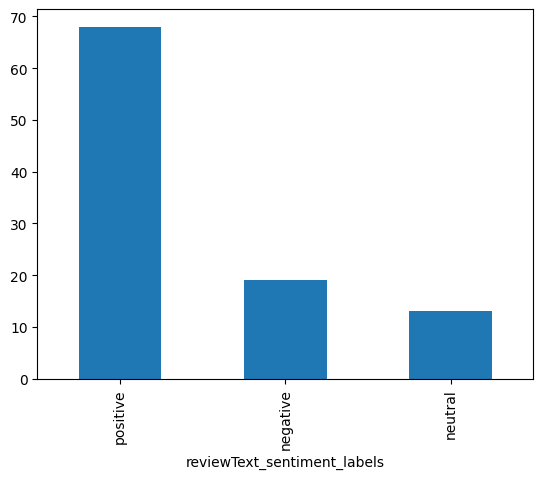

In [21]:
data['reviewText_sentiment_labels'].value_counts().plot.bar()

In [22]:
pipeline = pipeline('sentiment-analysis')

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [26]:
transformer_labels = []

for review in data['reviewText_clean'].values:
    sentiment_list = pipeline(review)
    sentiment_label = [label['label'] for label in sentiment_list]
    transformer_labels.append(sentiment_label)

data['reviewText_sentiment_label'] = transformer_labels

<Axes: xlabel='reviewText_sentiment_label'>

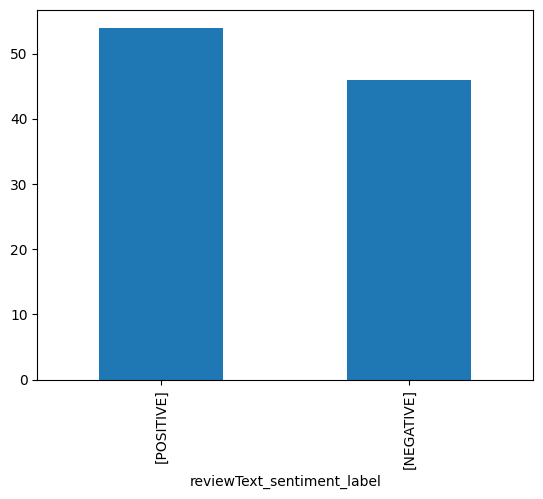

In [27]:
data['reviewText_sentiment_label'].value_counts().plot.bar()